In [1]:
# ============================================================
# Imports
# ============================================================
import re
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter, LogLocator, NullFormatter

from spicelib import RawRead
from spicelib.log.semi_dev_op_reader import opLogReader   # solo si usas LTspice para el .op

from prettytable import PrettyTable
from si_prefix import si_format as num2eng

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

trapz = getattr(np, "trapezoid", None) or np.trapz   # compatibilidad numpy

In [2]:
# ============================================================
# Funciones auxiliares
# ============================================================
def format_loglog_axes(ax, y_unit="", labelsize=14, weight="normal"):
    ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 3, 5, 7), numticks=20))
    ax.yaxis.set_major_formatter(EngFormatter(unit=y_unit))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="both", which="major", labelsize=labelsize)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight(weight)


def format_freq_axis(ax, labelsize=14, weight="normal"):
    ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    ax.tick_params(axis="x", which="major", labelsize=labelsize)
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight(weight)

In [3]:
# ============================================================
# Punto de operación (Operating Point) — LTspice
# Lectura del .log con spicelib.opLogReader + tabla formateada
# ============================================================
LOG_LTSPICE = "inv_op.log"

# --- Lectura del log ---
op_data = opLogReader(LOG_LTSPICE)
mosfets = op_data["bsim4 mosfets"]   # dict: {nombre_transistor: {param: valor}}

devices = list(mosfets.keys())        # columnas -> transistores
params  = ["Id", "Vgs", "Vds", "Vbs", "Vth", "Vdsat",
           "Gm", "Gds", "Gmb", "Cbd", "Cbs"]   # filas -> parámetros

# --- Tabla: filas = parámetros, columnas = transistores ---
table = PrettyTable()
table.field_names = ["Parámetro"] + devices

for p in params:
    row = [p]
    for dev in devices:
        row.append(num2eng(mosfets[dev][p]))
    table.add_row(row)

print(f"Punto de operación — {LOG_LTSPICE}\n")
print("ID del transistor U1 (NMOS):", num2eng(mosfets[devices[0]]["Id"]))
print("ID del transistor U2 (PMOS):", num2eng(mosfets[devices[1]]["Id"]))
print(devices)
print(table)

Punto de operación — inv_op.log

ID del transistor U1 (NMOS): 119.0 µ
ID del transistor U2 (PMOS): -119.0 µ
['u0:x1:m0', 'u1:x1:m0']
+-----------+----------+----------+
| Parámetro | u0:x1:m0 | u1:x1:m0 |
+-----------+----------+----------+
|     Id    | 119.0 µ  | -119.0 µ |
|    Vgs    |   1.6    |  -1.6    |
|    Vds    | 438.0 m  |  -2.9    |
|    Vbs    |   0.0    |   0.0    |
|    Vth    | 699.0 m  | -789.0 m |
|   Vdsat   | 717.0 m  | -703.0 m |
|     Gm    | 139.0 µ  | 245.0 µ  |
|    Gds    | 162.0 µ  |  1.8 µ   |
|    Gmb    |  56.0 µ  | 111.0 µ  |
|    Cbd    |  1.3 f   |  2.6 f   |
|    Cbs    |  1.6 f   |  3.9 f   |
+-----------+----------+----------+


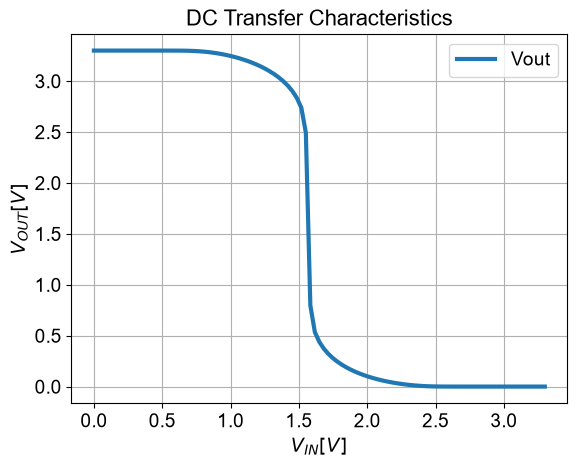

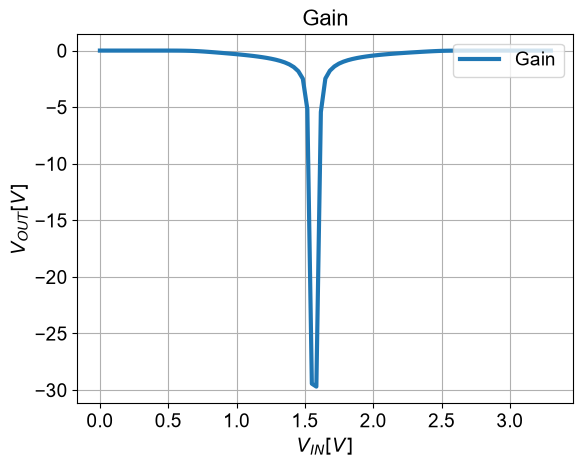

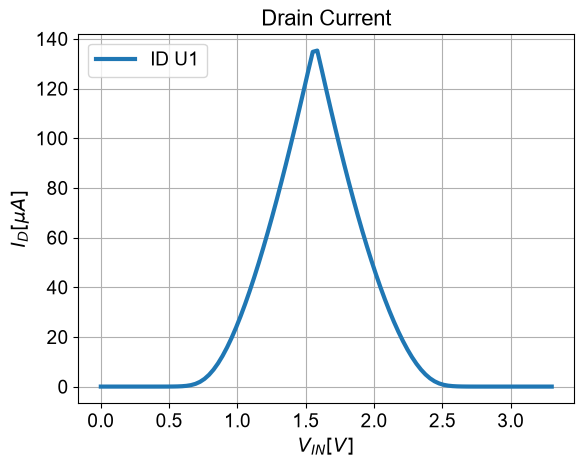

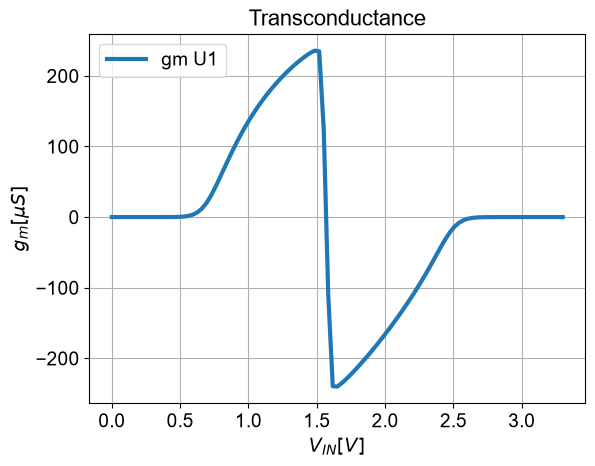

In [4]:
# Plot de caracteristicas de DC de un inversor CMOS a partir de un barrido de voltaje en la entrada.
# # --- Ruta a tu archivo .raw de LTspice ---
RAW_LTSPICE = "inv_dc.raw"

# --- Lectura ---
raw = RawRead(RAW_LTSPICE)
# raw.get_trace_names()  # descomenta para ver todos los nombres disponibles

vin  = raw.get_trace("V3").get_wave()          # nodo de barrido (VIN)
vout = raw.get_trace("V(vout)").get_wave()       # salida del inversor
id_u1 = raw.get_trace("Ix(u1:d)").get_wave()    # corriente de drenador de U1 (NMOS)

# --- gm = dID/dVGS ---
# En este circuito VGS(U1) = VIN (la fuente de U1 está a 0V), así que
# derivamos ID respecto al mismo eje de barrido VIN.
# OJO: como VDS(U1)=VOUT también varía en este barrido, esta gm mezcla
# el efecto de VGS y VDS a lo largo de la curva de conmutación —
# no es la gm de pequeña señal a VDS constante.
gm_u1 = np.gradient(id_u1, vin)
gain = np.gradient(vout, vin)

# --- Gráficas ---
plt.plot(vin, vout, linewidth = 3, label='Vout')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('DC Transfer Characteristics', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{OUT} [V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(vin, gain, linewidth = 3, label='Gain')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('Gain', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{OUT} [V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(vin, id_u1 * 1e6, linewidth = 3, label='ID U1')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('Drain Current', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$I_{D} [µA]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(vin, gm_u1 * 1e6, linewidth = 3, label='gm U1')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('Transconductance', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_m [µS]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

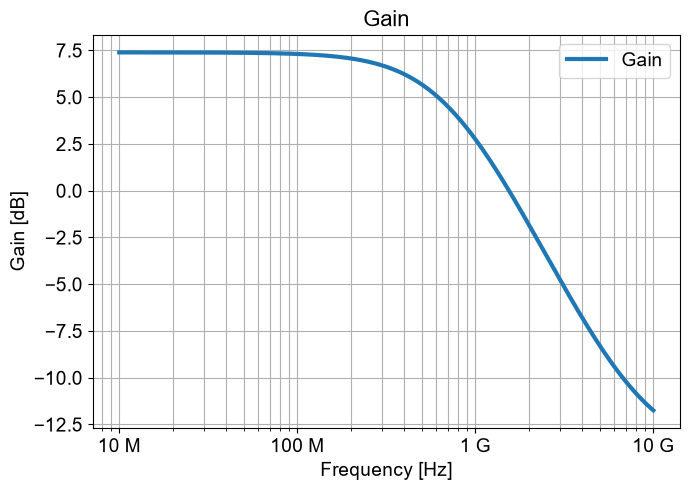

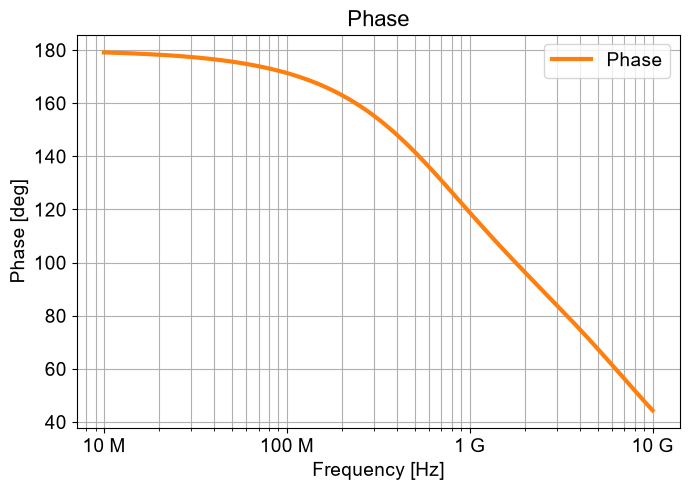

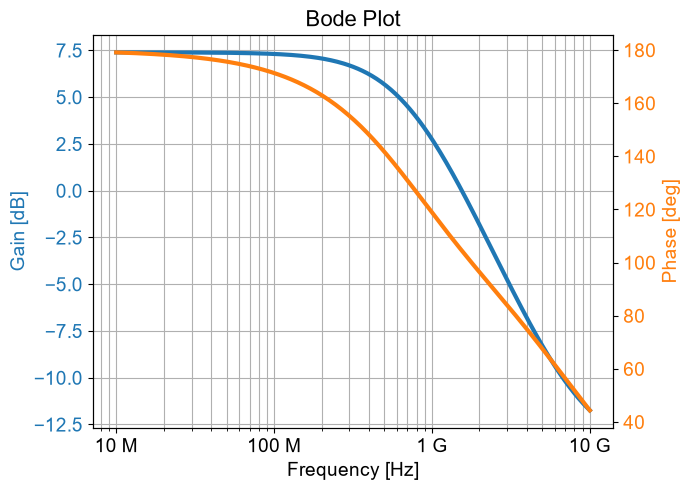

+---------------------------------+------------+
|             Métrica             |   Valor    |
+---------------------------------+------------+
|    Ganancia a baja frecuencia   |  7.39 dB   |
|      Ancho de banda (-3dB)      | 724.4 MHz  |
| Frecuencia de ganancia unitaria |  1.5 GHz   |
|    Fase en ganancia unitaria    | 104.46 deg |
+---------------------------------+------------+


In [ ]:
# ============================================================
# Bode plot del inversor CMOS — LTspice
# (mismo script de antes, con eje de frecuencia en prefijos de ingeniería)
# ============================================================
from spicelib import RawRead
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
from prettytable import PrettyTable
from si_prefix import si_format as num2eng

RAW_LTSPICE = "Inverter_DCSweep.raw"


def format_freq_axis(ax):
    """Aplica formato de prefijos de ingeniería solo al eje de frecuencia (semilogx)."""
    ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))


raw = RawRead(RAW_LTSPICE)
freq = np.abs(raw.get_trace("frequency").get_wave())
vout = raw.get_trace("V(vout)").get_wave()

gain_db   = 20 * np.log10(np.abs(vout))
phase_deg = np.angle(vout, deg=True)

# --- Métricas (igual que antes) ---
low_freq_gain_db = gain_db[0]
target_bw = low_freq_gain_db - 3
idx_bw = np.where(gain_db <= target_bw)[0][0]
bandwidth = np.exp(np.interp(target_bw, [gain_db[idx_bw - 1], gain_db[idx_bw]],
                              [np.log(freq[idx_bw - 1]), np.log(freq[idx_bw])]))
idx_ug = np.where(gain_db <= 0)[0][0]
f_unity = np.exp(np.interp(0, [gain_db[idx_ug - 1], gain_db[idx_ug]],
                            [np.log(freq[idx_ug - 1]), np.log(freq[idx_ug])]))
phase_at_unity = np.interp(np.log(f_unity), [np.log(freq[idx_ug - 1]), np.log(freq[idx_ug])],
                            [phase_deg[idx_ug - 1], phase_deg[idx_ug]])

# --- Gráfica 1: Ganancia en dB ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(freq, gain_db, linewidth=3, label="Gain")
ax.legend(prop={"size": 14}, loc="upper right")
ax.set_title("Gain", fontsize=16)
ax.set_xlabel("Frequency [Hz]", fontsize=14)
ax.set_ylabel("Gain [dB]", fontsize=14)
format_freq_axis(ax)
ax.grid(True, which="both")
plt.tight_layout()
plt.show()

# --- Gráfica 2: Fase en grados ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(freq, phase_deg, linewidth=3, color="tab:orange", label="Phase")
ax.legend(prop={"size": 14}, loc="upper right")
ax.set_title("Phase", fontsize=16)
ax.set_xlabel("Frequency [Hz]", fontsize=14)
ax.set_ylabel("Phase [deg]", fontsize=14)
format_freq_axis(ax)
ax.grid(True, which="both")
plt.tight_layout()
plt.show()

# --- Gráfica 3: Ganancia y fase con doble eje Y ---
fig, ax1 = plt.subplots(figsize=(7, 5))
color1 = "tab:blue"
ax1.semilogx(freq, gain_db, linewidth=3, color=color1, label="Gain")
ax1.set_xlabel("Frequency [Hz]", fontsize=14)
ax1.set_ylabel("Gain [dB]", fontsize=14, color=color1)
ax1.tick_params(axis="y", labelcolor=color1, labelsize=14)
ax1.tick_params(axis="x", labelsize=14)
format_freq_axis(ax1)
ax1.grid(True, which="both")

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.semilogx(freq, phase_deg, linewidth=3, color=color2, label="Phase")
ax2.set_ylabel("Phase [deg]", fontsize=14, color=color2)
ax2.tick_params(axis="y", labelcolor=color2, labelsize=14)

plt.title("Bode Plot", fontsize=16)
fig.tight_layout()
plt.show()

# --- Tabla de métricas ---
table = PrettyTable()
table.field_names = ["Métrica", "Valor"]
table.add_row(["Ganancia a baja frecuencia", f"{low_freq_gain_db:.2f} dB"])
table.add_row(["Ancho de banda (-3dB)", num2eng(bandwidth) + "Hz"])
table.add_row(["Frecuencia de ganancia unitaria", num2eng(f_unity) + "Hz"])
table.add_row(["Fase en ganancia unitaria", f"{phase_at_unity:.2f} deg"])
print(table)

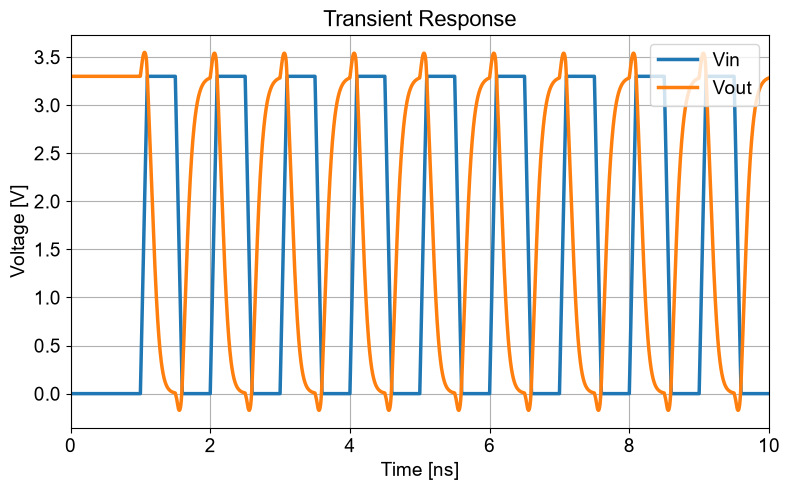

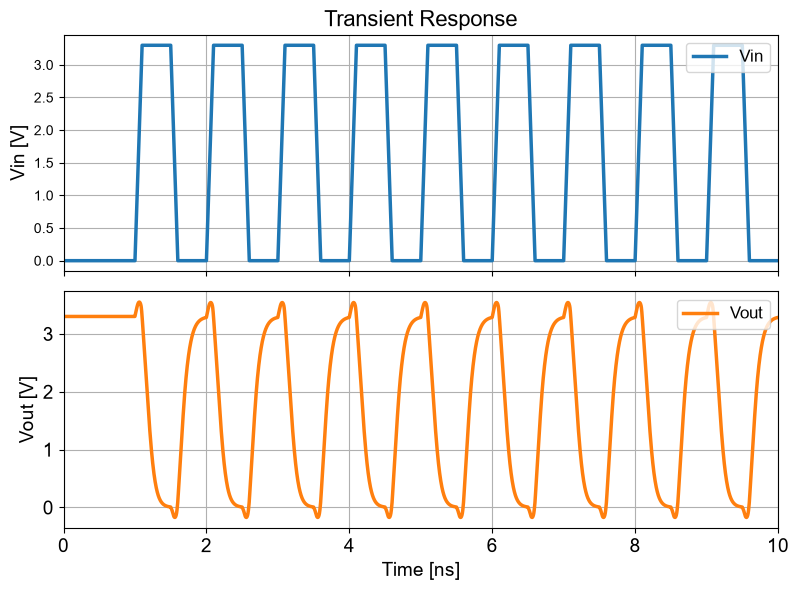

In [62]:
# ============================================================
# Transitorio del inversor CMOS gf180mcuD — LTspice
# Grafica 1: Vin y Vout superpuestos
# Grafica 2: Vin y Vout en subplots apilados (eje x compartido)
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

RAW_LTSPICE = "inv_tran.raw"

# --- Lectura ---
raw = RawRead(RAW_LTSPICE)
t    = raw.get_trace("time").get_wave()
vin  = raw.get_trace("V(vin)").get_wave()
vout = raw.get_trace("V(vout)").get_wave()

t_ns = t * 1e9   # tiempo en ns para que los ejes sean mas legibles

# ============================================================
# --- Grafica 1: Vin y Vout superpuestos ---
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(t_ns, vin, linewidth=2.5, label='Vin')
plt.plot(t_ns, vout, linewidth=2.5, label='Vout')
plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="upper right")
plt.title('Transient Response', weight='normal', fontsize=16)
plt.xlabel('Time [ns]', weight='normal', fontsize=14)
plt.ylabel('Voltage [V]', weight='normal', fontsize=14)
plt.xticks(weight="normal", fontsize=14)
plt.yticks(weight="normal", fontsize=14)
plt.xlim(0, 10)
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# --- Grafica 2: Vin (arriba) y Vout (abajo), eje x compartido ---
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(t_ns, vin, linewidth=2.5, color='tab:blue', label='Vin')
ax1.set_ylabel('Vin [V]', weight='normal', fontsize=14)
ax1.legend(prop={"size": 12}, loc="upper right")
ax1.grid(True)
ax1.set_title('Transient Response', weight='normal', fontsize=16)

ax2.plot(t_ns, vout, linewidth=2.5, color='tab:orange', label='Vout')
ax2.set_ylabel('Vout [V]', weight='normal', fontsize=14)
ax2.set_xlabel('Time [ns]', weight='normal', fontsize=14)
ax2.legend(prop={"size": 12}, loc="upper right")
ax2.grid(True)

xlimits = (0, 10)
ax1.set_xlim(xlimits)
ax2.set_xlim(xlimits)

plt.xticks(weight="normal", fontsize=14)
plt.yticks(weight="normal", fontsize=14)



plt.tight_layout()
plt.show()

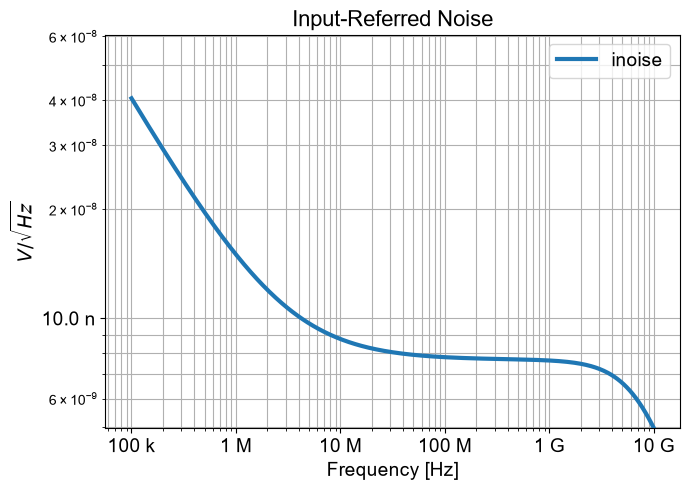

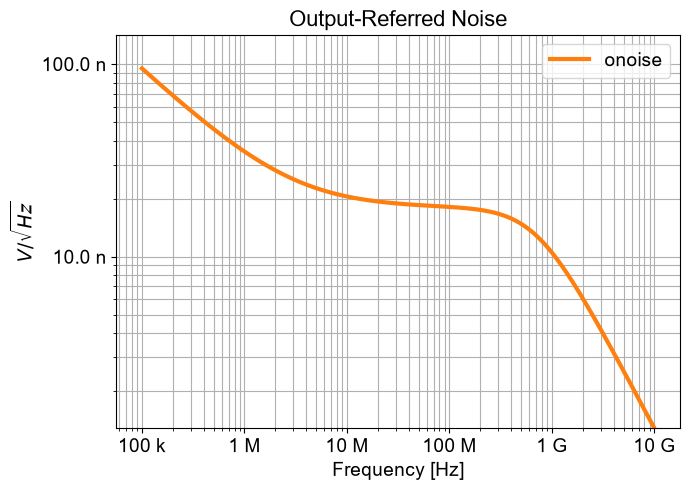

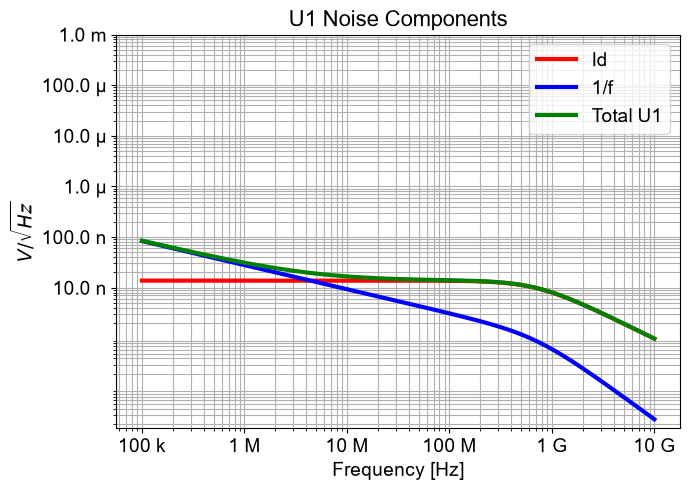

+---------------------------------+------------------+
|             Métrica             |      Valor       |
+---------------------------------+------------------+
|         Onoise @ 1.0 MHz        | 35.1 nV/sqrt(Hz) |
|         Inoise @ 1.0 MHz        | 15.0 nV/sqrt(Hz) |
|  Gain (onoise/inoise) @ 1.0 MHz |      2.342       |
|      U1 flicker corner freq     |     4.5 MHz      |
|        Onoise white floor       | 1.6 nV/sqrt(Hz)  |
|        Inoise white floor       | 5.6 nV/sqrt(Hz)  |
| Onoise RMS (100.0 kHz-10.0 GHz) |     597.1 µV     |
| Inoise RMS (100.0 kHz-10.0 GHz) |     660.6 µV     |
+---------------------------------+------------------+


In [74]:
# ============================================================
# Análisis de ruido del inversor CMOS gf180mcuD — LTspice
# 3 gráficas: inoise, onoise, componentes de ruido de U1
# Ejes con prefijos de ingeniería (n, u, k, M, G...)
# Métricas: onoise/inoise @ f0, ganancia onoise/inoise, corner freq
#           flicker de U1, piso de ruido blanco, ruido RMS integrado
# ============================================================
RAW_LTSPICE = "inv_noise.raw"
F_REPORT = 1e6   # frecuencia de referencia para el reporte puntual (ajustable)

# numpy renombro trapz -> trapezoid en versiones recientes; esto funciona con ambas
trapz = getattr(np, "trapezoid", None) or np.trapz

# --- Lectura ---
raw = RawRead(RAW_LTSPICE)
freq      = np.abs(raw.get_trace("frequency").get_wave())
onoise = np.abs(raw.get_trace("v(onoise)").get_wave())
inoise = np.abs(raw.get_trace("v(inoise)").get_wave())
id_u1  = np.abs(raw.get_trace("v(u1:x1:m0.id)").get_wave())
f1_u1  = np.abs(raw.get_trace("v(u1:x1:m0.1overf)").get_wave())
tot_u1 = np.abs(raw.get_trace("v(u1:x1:m0)").get_wave())

# find min and max frequency for xticks and separate them into decades
min_freq = np.min(freq)
max_freq = np.max(freq)
min_decade = int(np.floor(np.log10(min_freq)))
max_decade = int(np.ceil(np.log10(max_freq)))
xtickslabel = [10 ** i for i in range(min_decade, max_decade + 1)]

# ============================================================
# --- Gráfica 1: inoise ---
# ============================================================
plt.subplots(figsize=(7, 5))
plt.loglog(freq, inoise, linewidth=3, label="inoise")
plt.legend(prop={"size": 14}, loc="upper right")
plt.title("Input-Referred Noise", fontsize=16)
plt.xlabel("Frequency [Hz]", fontsize=14)
plt.ylabel(r"$V/\sqrt{Hz}$", fontsize=14)
plt.grid(True, which="both")
plt.xticks(xtickslabel,[num2eng(x,0) for x in xtickslabel], weight='normal',fontsize=14)
ytickslabel = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.ylim(min(inoise), max(inoise)*1.5)
plt.tight_layout()
plt.show()

# ============================================================
# --- Gráfica 2: onoise ---
# ============================================================
plt.subplots(figsize=(7, 5))
plt.loglog(freq, onoise, linewidth=3, color="tab:orange", label="onoise")
plt.legend(prop={"size": 14}, loc="upper right")
plt.title("Output-Referred Noise", fontsize=16)
plt.xlabel("Frequency [Hz]", fontsize=14)
plt.ylabel(r"$V/\sqrt{Hz}$", fontsize=14)
plt.grid(True, which="both")
plt.xticks(xtickslabel,[num2eng(x,0) for x in xtickslabel], weight='normal',fontsize=14)
ytickslabel = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.ylim(min(onoise), max(onoise)*1.5)
plt.tight_layout()
plt.show()

# ============================================================
# --- Gráfica 3: componentes de ruido de U1 (Id, 1/f, Total) ---
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(freq, id_u1, linewidth=3, color="red", label="Id")
ax.loglog(freq, f1_u1, linewidth=3, color="blue", label="1/f")
ax.loglog(freq, tot_u1, linewidth=3, color="green", label="Total U1")
ax.legend(prop={"size": 14}, loc="upper right")
ax.set_title("U1 Noise Components", fontsize=16)
ax.set_xlabel("Frequency [Hz]", fontsize=14)
ax.set_ylabel(r"$V/\sqrt{Hz}$", fontsize=14)
ax.grid(True, which="both")
plt.xticks(xtickslabel,[num2eng(x,0) for x in xtickslabel], weight='normal',fontsize=14)
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# --- Métricas ---
# ============================================================
onoise_at_f = np.interp(np.log10(F_REPORT), np.log10(freq), onoise)
inoise_at_f = np.interp(np.log10(F_REPORT), np.log10(freq), inoise)
gain_at_f = onoise_at_f / inoise_at_f   # onoise/inoise = |ganancia| del circuito

# frecuencia de esquina de flicker de U1: donde 1/f cruza a id
diff = f1_u1 - id_u1
cross_idx = np.where(np.diff(np.sign(diff)))[0]
if len(cross_idx) > 0:
    idx = cross_idx[0]
    f_corner = np.exp(np.interp(0, [diff[idx], diff[idx + 1]], [np.log(freq[idx]), np.log(freq[idx + 1])]))
else:
    f_corner = np.nan

# piso de ruido blanco: promedio de los ultimos puntos (alta frecuencia)
onoise_floor = np.mean(onoise[-20:])
inoise_floor = np.mean(inoise[-20:])

# ruido RMS integrado sobre toda la banda simulada:
# RMS = sqrt( integral( PSD(f)^2 df ) ), PSD en V/sqrt(Hz) -> RMS en V
onoise_rms = np.sqrt(trapz(onoise**2, freq))
inoise_rms = np.sqrt(trapz(inoise**2, freq))

table = PrettyTable()
table.field_names = ["Métrica", "Valor"]
table.add_row([f"Onoise @ {num2eng(F_REPORT)}Hz", num2eng(onoise_at_f) + "V/sqrt(Hz)"])
table.add_row([f"Inoise @ {num2eng(F_REPORT)}Hz", num2eng(inoise_at_f) + "V/sqrt(Hz)"])
table.add_row([f"Gain (onoise/inoise) @ {num2eng(F_REPORT)}Hz", f"{gain_at_f:.3f}"])
table.add_row(["U1 flicker corner freq", num2eng(f_corner) + "Hz"])
table.add_row(["Onoise white floor", num2eng(onoise_floor) + "V/sqrt(Hz)"])
table.add_row(["Inoise white floor", num2eng(inoise_floor) + "V/sqrt(Hz)"])
table.add_row([f"Onoise RMS ({num2eng(freq[0])}Hz-{num2eng(freq[-1])}Hz)", num2eng(onoise_rms) + "V"])
table.add_row([f"Inoise RMS ({num2eng(freq[0])}Hz-{num2eng(freq[-1])}Hz)", num2eng(inoise_rms) + "V"])

print(table)